# Thử nghiệm Quy trình Trích xuất Đa phương thức (Multimodal Data Ingestion)
**Mục tiêu:** Notebook này nhằm mục đích thử nghiệm và trực quan hóa bước đầu tiên trong pipeline Multimodal RAG:
1. Tách âm thanh từ file video bài giảng (`.mp4`).
2. Sử dụng mô hình ASR **PhoWhisper** để bóc băng (transcript) giọng nói tiếng Việt kèm mốc thời gian (timestamps).
3. Trích xuất các khung hình chính (keyframes) từ video.
4. Sử dụng **PaddleOCR** để nhận diện và trích xuất văn bản từ ảnh slide.

In [1]:
import os
os.environ["PATH"] += r";C:\Users\longn\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [2]:
# # Video processing
# %pip install -q moviepy opencv-python matplotlib

# # Audio processing
# %pip install -q librosa soundfile

# # OCR
# %pip install -q paddlepaddle paddleocr

# # AI models
# %pip install -q transformers accelerate torch

# # Image processing
# %pip install -q pillow

# # (optional) DeepSeek OCR
# %pip install -q timm

In [3]:
import os
import cv2
import torch
import subprocess
import numpy as np
import matplotlib.pyplot as plt

# Video & Audio
from moviepy import VideoFileClip
import librosa
import soundfile as sf

# Image
from PIL import Image

# OCR
from paddleocr import PaddleOCR

# AI models
from transformers import pipeline

c:\Users\longn\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
c:\Users\longn\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [4]:
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

video_path = os.path.join(BASE_DIR, "data", "raw_videos", "videoplayback.mp4")
audio_path = os.path.join(BASE_DIR, "notebooks", "testdata", "extracted_audio.wav")

os.makedirs(os.path.dirname(audio_path), exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("Video path:", video_path)
print("Video exists:", os.path.exists(video_path))

BASE_DIR: f:\University of information technology's Courses\CS431_DL\T_RAG_for_Video_Retrieval
Video path: f:\University of information technology's Courses\CS431_DL\T_RAG_for_Video_Retrieval\data\raw_videos\videoplayback.mp4
Video exists: True


## Trich xuat am thanh tu video

In [5]:
def extract_audio(video_path, audio_path):

    print("Dang trich xuat am thanh tu:", video_path)

    ffmpeg_path = r"C:\Users\longn\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin\ffmpeg.exe"

    video_path = os.path.abspath(video_path)
    audio_path = os.path.abspath(audio_path)

    command = [
        ffmpeg_path,
        "-y",
        "-i", video_path,
        "-vn",
        "-acodec", "pcm_s16le",
        "-ar", "16000",
        "-ac", "1",
        audio_path
    ]

    result = subprocess.run(command, capture_output=True, text=True)

    if result.returncode != 0:
        print("FFmpeg error:\n", result.stderr)
    else:
        print("Da luu file tai:", audio_path)

In [6]:
# extract_audio(video_path, audio_path)

In [7]:
%pip install faster-whisper

Note: you may need to restart the kernel to use updated packages.


In [8]:
from faster_whisper import WhisperModel
import torch


def transcribe_audio(audio_path):

    print("Đang tải mô hình Faster Whisper...")

    model = WhisperModel(
        "small",
        device="cuda" if torch.cuda.is_available() else "cpu",
        compute_type="float16" if torch.cuda.is_available() else "int8"
    )

    print("Đang transcribe audio...")

    segments, info = model.transcribe(
        audio_path,
        language="vi",
        beam_size=5,
        vad_filter=True,
        condition_on_previous_text=False,
        temperature=0
    )

    print("\nKết quả transcript (5 đoạn đầu):\n")

    transcript = []

    for i, segment in enumerate(segments):
        start = segment.start
        end = segment.end
        text = segment.text.strip()

        transcript.append(text)

        if i < 5:
            print(f"[{start:.2f}s -> {end:.2f}s] {text}")

    full_text = " ".join(transcript)

    return {
        "text": full_text
    }

In [9]:
import librosa

audio, sr = librosa.load(audio_path, sr=16000)

print("Audio length:", len(audio)/sr, "seconds")

Audio length: 930.980875 seconds


In [10]:
# transcript_data = transcribe_audio(audio_path)

#### Trích xuất keyframe

Trich xuat keyframe tai giay thu 500
Da luu frame tai: ./testdata/extracted_frame_10s.jpg


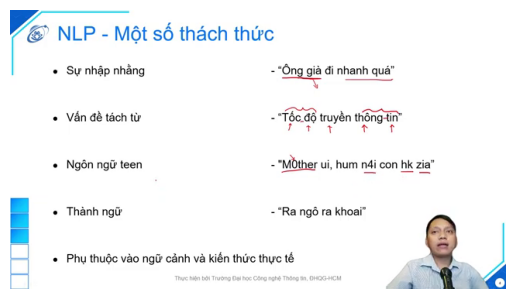

File tồn tại: True


In [11]:
def extrac_keyframe(video_path, time_in_seconds, output_path):
    print(f"Trich xuat keyframe tai giay thu {time_in_seconds}")
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_id = int(fps * time_in_seconds)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()

    if ret:
        cv2.imwrite(output_path, frame)
        print(f"Da luu frame tai: {output_path}")

        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()

    else:
        print("Khong the trich xuat khung hinh.")

    cap.release()

FRAME_PATH = "./testdata/extracted_frame_10s.jpg"

extrac_keyframe(video_path, 500, FRAME_PATH)

# Kiểm tra file
import os
print("File tồn tại:", os.path.exists(FRAME_PATH))

In [12]:
print(FRAME_PATH)

./testdata/extracted_frame_10s.jpg


Trich xuat keyframe tai giay thu 100
Da luu frame tai: ./testdata/extracted_frame_10s.jpg


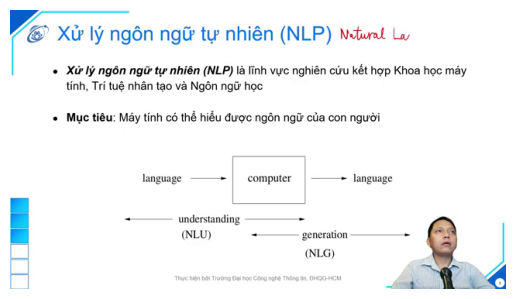

In [13]:
# Chạy thử nghiệm
extrac_keyframe(video_path, 100, FRAME_PATH)

In [14]:
# %pip install transformers==4.41.2
# %pip install accelerate
# %pip install sentencepiece

In [15]:
# !python -m pip install --upgrade pip

In [16]:
# pip install paddlepaddle==2.6.1

In [17]:
%pip install paddlepaddle

Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install paddleocr

Note: you may need to restart the kernel to use updated packages.


In [19]:
import paddle
print(paddle.__version__)

c:\Users\longn\AppData\Local\Programs\Python\Python311\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


3.3.0


In [20]:
from paddleocr import PaddleOCR

paddle_ocr = PaddleOCR(use_angle_cls=True, lang='vi', enable_mkldnn=False)

def run_ocr(image_path):
    print(f"\nReading image: {image_path}")
    
    result = paddle_ocr.predict(image_path)
    
    texts = []
    
    if not result or len(result) == 0 or result[0] is None:
        print("Không tìm thấy văn bản nào trong ảnh.")
        return ""
        
    res = result[0]
    
    if isinstance(res, dict) and 'rec_texts' in res:
        texts_list = res.get('rec_texts', [])
        scores_list = res.get('rec_scores', [])
        
        for text, conf in zip(texts_list, scores_list):
            if conf > 0.5:
                texts.append(text)
                
    elif hasattr(res, 'rec_texts'):
        texts_list = getattr(res, 'rec_texts', [])
        scores_list = getattr(res, 'rec_scores', [])
        
        for text, conf in zip(texts_list, scores_list):
            if conf > 0.5:
                texts.append(text)

    elif isinstance(res, list):
        for line in res:
            if len(line) >= 2 and isinstance(line[1], (tuple, list)):
                text = line[1][0]
                conf = line[1][1]
                if conf > 0.5:
                    texts.append(text)
    else:
        print("Định dạng kết quả mới chưa được hỗ trợ, kết quả gốc là:", type(res))
        print(res)
        
    final_text = "\n".join(texts)
    return final_text

C:\Users\longn\AppData\Local\Temp\ipykernel_14508\2322571052.py:3: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  paddle_ocr = PaddleOCR(use_angle_cls=True, lang='vi', enable_mkldnn=False)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\longn\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\longn\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\longn\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\longn\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('latin_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\longn\.paddlex\official_models\latin_PP-OCRv5_mobile_rec`.


In [21]:
import os
print(os.getcwd())

f:\University of information technology's Courses\CS431_DL\T_RAG_for_Video_Retrieval\notebooks


In [22]:
# %pip uninstall paddlepaddle -y
# %pip install paddlepaddle==2.6.1

In [23]:
# # Chạy thử nghiệm OCR

# image_path = "testdata/extracted_frame_10s.jpg"

# slide_text = run_ocr(image_path)

# print("\nFinal OCR Text:\n")
# print(slide_text)

In [24]:
%pip install google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [25]:
# import google.generativeai as genai
# import PIL.Image

# # Điền API Key của bạn vào đây
# genai.configure(api_key="YOUR_API_KEY")

# # Khởi tạo model (bản Flash siêu nhanh và nhẹ)
# model = genai.GenerativeModel('gemini-1.5-flash')

# def run_gemini_ocr(image_path):
#     print(f"Reading image: {image_path}")
#     img = PIL.Image.open(image_path)
    
#     # Prompt yêu cầu model chỉ trích xuất text
#     prompt = "Hãy trích xuất toàn bộ văn bản trong bức ảnh slide này. Giữ nguyên cấu trúc, dấu câu và định dạng (nếu có tiêu đề hoặc gạch đầu dòng, hãy dùng markdown)."
    
#     response = model.generate_content([prompt, img])
#     return response.text

# # Chạy thử
# slide_text = run_gemini_ocr("testdata/extracted_frame_10s.jpg")
# print(slide_text)

In [26]:
# %pip install transformers qwen-vl-utils torch torchvision

In [ ]:
# %pip install --upgrade transformers

: 

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch

print("Đang tải mô hình Qwen2-VL (chỉ tải 1 lần đầu tiên khoảng vài GB)...")

# Khởi tạo model từ Hugging Face
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", 
    torch_dtype="auto", 
    device_map="auto" # Tự động nhận diện và đẩy lên GPU nếu máy có Card rời
)

# Khởi tạo bộ xử lý ảnh/text
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

def run_transformers_ocr(image_path):
    print(f"\nĐang trích xuất ảnh: {image_path}")
    
    # Tạo prompt yêu cầu mô hình bóc chữ
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": "Hãy trích xuất chính xác toàn bộ văn bản tiếng Việt trong bức ảnh này. Giữ nguyên định dạng và không bịa thêm chữ."},
            ],
        }
    ]

    # Xử lý input cho mô hình
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    # Chạy dự đoán
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=1024)
        
    # Cắt bỏ phần input prompt ra khỏi kết quả
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    # Giải mã kết quả thành dạng Text
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    
    return output_text[0]


image_path = "testdata/extracted_frame_10s.jpg"
slide_text = run_transformers_ocr(image_path)

print("\n" + "="*40)
print("KẾT QUẢ OCR TỪ TRANSFORMERS (QWEN2-VL):")
print("="*40)
print(slide_text)

Đang tải mô hình Qwen2-VL (chỉ tải 1 lần đầu tiên khoảng vài GB)...


[2026-03-13 10:30:14,538] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-03-13 10:30:14,551] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/config.json "HTTP/1.1 200 OK"
[2026-03-13 10:30:14,842] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
[2026-03-13 10:30:15,163] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct/resolve/main/model.safetensors.index.json "HTTP/1.1 307 Temporary Redirect"
[2026-03-13 10:30:15,180] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2-VL-2B-Instruct/895c3a49bc3fa70a340399125c650a463535e71c/model.safetensors.index.json "HT


Đang trích xuất ảnh: testdata/extracted_frame_10s.jpg
